In [ ]:
!pip install -q kagglehub

import kagglehub
import os
import shutil


print("Starting download...")
download_path = kagglehub.dataset_download("yangsangtai/tiny-genimage")

print("\n Dataset downloaded to temporary cache:")
print(download_path)


TARGET_DIR = "/content/tiny_genimage"
if not os.path.exists(TARGET_DIR):
    shutil.copytree(download_path, TARGET_DIR)
    print(f"\n Files moved to: {TARGET_DIR}")

print("\n🔍 Generators found in dataset:")
!ls {TARGET_DIR}

Starting download...


100%|██████████| 7.77G/7.77G [01:29<00:00, 93.4MB/s]

Extracting files...



 Dataset downloaded to temporary cache:
/root/.cache/kagglehub/datasets/yangsangtai/tiny-genimage/versions/1

 Files moved to: /content/tiny_genimage

🔍 Generators found in dataset:
imagenet_ai_0419_biggan  imagenet_ai_0424_wukong  imagenet_midjourney
imagenet_ai_0419_vqdm	 imagenet_ai_0508_adm
imagenet_ai_0424_sdv5	 imagenet_glide


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from torchvision import models

class bceLoss(nn.Module):
    def __init__(self):
        super(bceLoss, self).__init__()
        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, preds, labels):

        return self.loss_fn(preds, labels)

class SSP_Placeholder(nn.Module):
    def __init__(self):
        super(SSP_Placeholder, self).__init__()
        self.backbone = models.resnet18(pretrained=True)

        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

def ssp():
    return SSP_Placeholder()

class TrainOptions:
    def __init__(self):
        self.batch_size = 32
        self.input_size = 256
        self.lr = 1e-4
        self.epoch = 10
        self.save_path = './ssp_checkpoints_combined_genimage/'
        self.load = None
        self.gpu_id = '0'


opt = TrainOptions()


if not os.path.exists(opt.save_path):
    os.makedirs(opt.save_path)
    print(f"Created checkpoint directory at: {opt.save_path}")

print("SSP Model and Configuration defined based on important.ipynb.")

Created checkpoint directory at: ./ssp_checkpoints_combined_genimage/
SSP Model and Configuration defined based on important.ipynb.


In [ ]:

import os
from torch.utils.data import ConcatDataset, DataLoader
from torchvision import datasets, transforms
import torch

IMAGE_SIZE = 256

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATA_ROOT = "/content/tiny_genimage"

all_subsets = [
    'imagenet_ai_0419_biggan', 'imagenet_ai_0419_vqdm',
    'imagenet_ai_0424_sdv5', 'imagenet_ai_0424_wukong',
    'imagenet_ai_0508_adm', 'imagenet_glide',
    'imagenet_midjourney'
]

train_datasets_list = []
val_full_list = []

print("Gathering ALL generator subsets...")
for folder in all_subsets:

    t_path = os.path.join(DATA_ROOT, folder, 'train')
    if os.path.exists(t_path):
        train_datasets_list.append(datasets.ImageFolder(t_path, transform=train_transforms))

    v_path = os.path.join(DATA_ROOT, folder, 'val')
    if os.path.exists(v_path):
        val_full_list.append(datasets.ImageFolder(v_path, transform=val_test_transforms))

    print(f"Loaded: {folder}")

super_train_dataset = ConcatDataset(train_datasets_list)
super_val_full_dataset = ConcatDataset(val_full_list)

TOTAL_VAL_IMAGES = len(super_val_full_dataset)
VAL_SIZE = int(0.5 * TOTAL_VAL_IMAGES)
TEST_SIZE = TOTAL_VAL_IMAGES - VAL_SIZE

val_dataset_split, test_dataset_split = torch.utils.data.random_split(
    super_val_full_dataset,
    [VAL_SIZE, TEST_SIZE],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(super_train_dataset, batch_size=opt.batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset_split, batch_size=opt.batch_size, shuffle=False, num_workers=2)
final_test_loader = DataLoader(test_dataset_split, batch_size=opt.batch_size, shuffle=False, num_workers=2)

print(f"\n Total Training Images (All Techs): {len(super_train_dataset)}")
print(f" Validation Set Size: {len(val_dataset_split)}")
print(f" Final Unbiased Test Set: {len(test_dataset_split)}")

Gathering ALL generator subsets...
Loaded: imagenet_ai_0419_biggan
Loaded: imagenet_ai_0419_vqdm
Loaded: imagenet_ai_0424_sdv5
Loaded: imagenet_ai_0424_wukong
Loaded: imagenet_ai_0508_adm
Loaded: imagenet_glide
Loaded: imagenet_midjourney

 Total Training Images (All Techs): 28000
 Validation Set Size: 3500
 Final Unbiased Test Set: 3500


In [ ]:
import torch
import torch.nn as nn
from datetime import datetime

step = 0
best_epoch = 0
best_accu = 0

def train(train_loader, model, optimizer, epoch, save_path):
    model.train()
    global step
    epoch_step = 0
    loss_all = 0
    total_correct = 0
    total_images = 0

    print(f'\n--- Starting Training Epoch {epoch:03d} ---')

    for i, (images, labels) in enumerate(train_loader, start=1):
        optimizer.zero_grad()
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float()

        preds = model(images)

        loss_fn = bceLoss().to(DEVICE)
        loss = loss_fn(preds, labels)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            probabilities = torch.sigmoid(preds)
            predicted_labels = (probabilities > 0.5).float()
            total_correct += (predicted_labels == labels).sum().item()
            total_images += images.size(0)

        step += 1
        epoch_step += 1
        loss_all += loss.item()

        if i % 100 == 0:
            current_train_acc = total_correct / total_images
            print(f'{datetime.now()} Epoch [{epoch:03d}], Step [{i:04d}/{len(train_loader)}], Loss: {loss.item():.4f}, Train Acc: {current_train_acc:.4f}')

    avg_loss = loss_all / epoch_step
    avg_train_acc = total_correct / total_images
    print(f"Epoch {epoch:03d} finished. Average Loss: {avg_loss:.4f}, Average Train Acc: {avg_train_acc:.4f}")

def val(val_loader, model, epoch, save_path):
    model.eval()
    global best_epoch, best_accu
    total_correct = 0
    total_images = 0

    print(f'\n--- Validating Epoch {epoch:03d} (Combined Set) ---')

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()

            res = model(images)
            probabilities = torch.sigmoid(res)
            predicted_labels = (probabilities > 0.5).float()

            total_correct += (predicted_labels == labels).sum().item()
            total_images += images.size(0)

    total_accu = total_correct / total_images
    print(f'Validation Results: Epoch {epoch}, Accuracy: {total_accu:.4f}')

    if total_accu > best_accu:
        best_accu = total_accu
        best_epoch = epoch
        torch.save(model.state_dict(), os.path.join(save_path, 'Net_epoch_best.pth'))
        print(f'New Best Model saved! Best Accu: {best_accu:.4f}')

    print(f'Epoch Summary: {epoch}, Current Val Accu: {total_accu:.4f}, Best Val Accu: {best_accu:.4f} at Epoch {best_epoch}')

In [ ]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def poly_lr(optimizer, initial_lr, epoch, max_epochs, power=0.9):
    lr = initial_lr * (1 - epoch / max_epochs)**power
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    return lr


model = ssp().to(DEVICE)

initial_lr = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)

if not os.path.exists(opt.save_path):
    os.makedirs(opt.save_path)
    print(f" Created save directory at: {opt.save_path}")

print("\n--- Start Training (Combined All Generators) ---")
print(f"Training on: {len(super_train_dataset)} total images (includes Midjourney)")
print(f"Validating on: {len(val_dataset_split)} mixed images")

best_epoch = 0
best_accu = 0
step = 0

for epoch in range(1, opt.epoch + 1):
    cur_lr = poly_lr(optimizer, initial_lr, epoch, opt.epoch)

    train(train_loader, model, optimizer, epoch, opt.save_path)

    val(val_loader, model, epoch, opt.save_path)

print("\n--- Training Complete ---")
print(f"Best Model saved from Epoch {best_epoch} with Validation Accuracy {best_accu:.4f}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]



--- Start Training (Combined All Generators) ---
Training on: 28000 total images (includes Midjourney)
Validating on: 3500 mixed images

--- Starting Training Epoch 001 ---
2026-04-17 12:57:15.524519 Epoch [001], Step [0100/875], Loss: 0.5059, Train Acc: 0.7316
2026-04-17 12:57:46.431793 Epoch [001], Step [0200/875], Loss: 0.3402, Train Acc: 0.7708
2026-04-17 12:58:16.848028 Epoch [001], Step [0300/875], Loss: 0.3705, Train Acc: 0.7895
2026-04-17 12:58:47.052829 Epoch [001], Step [0400/875], Loss: 0.3612, Train Acc: 0.8030
2026-04-17 12:59:18.423959 Epoch [001], Step [0500/875], Loss: 0.2832, Train Acc: 0.8116
2026-04-17 12:59:48.137908 Epoch [001], Step [0600/875], Loss: 0.5673, Train Acc: 0.8197
2026-04-17 13:00:17.218256 Epoch [001], Step [0700/875], Loss: 0.2536, Train Acc: 0.8264
2026-04-17 13:00:47.979879 Epoch [001], Step [0800/875], Loss: 0.4642, Train Acc: 0.8311
Epoch 001 finished. Average Loss: 0.3678, Average Train Acc: 0.8344

--- Validating Epoch 001 (Combined Set) ---
V

In [2]:
def test(test_loader, model):
    model.eval()
    total_correct = 0
    total_images = 0

    print("\n" + "="*40)
    print("STARTING FINAL TEST EVALUATION")
    print("="*40)

    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader, start=1):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()

            preds = model(images)

            probabilities = torch.sigmoid(preds)
            predicted_labels = (probabilities > 0.5).float()

            total_correct += (predicted_labels == labels).sum().item()
            total_images += images.size(0)

            if i % 50 == 0:
                print(f"Processing Batch [{i}/{len(test_loader)}]...")

    final_accuracy = total_correct / total_images

    print("\n" + "-"*40)
    print(f" FINAL ACCURACY on Test Set: {final_accuracy:.4f}")
    print(f" Correct: {total_correct} | Total: {total_images}")
    print("-"*40)

    return final_accuracy


final_model = ssp().to(DEVICE)

BEST_MODEL_PATH = os.path.join(opt.save_path, 'Net_epoch_best.pth')

if os.path.exists(BEST_MODEL_PATH):
    print(f"Loading best weights from: {BEST_MODEL_PATH}")
    final_model.load_state_dict(torch.load(BEST_MODEL_PATH))

    test(final_test_loader, final_model)
else:
    print(f" Error: Could not find {BEST_MODEL_PATH}. Did you finish training?")


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

def run_full_evaluation(model_path, test_loader, device):
    model = ssp().to(device)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f" Loaded weights from {model_path}")
    else:
        print(f" Error: {model_path} not found!")
        return

    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    print(" Running inference on test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real (0)', 'AI (1)'],
                yticklabels=['Real (0)', 'AI (1)'])
    plt.title('Confusion Matrix: Real vs AI Detection')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('confusion_matrix.png')
    plt.show()

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('roc_curve.png')
    plt.show()

    plt.figure(figsize=(15, 6))
    images, labels = next(iter(test_loader))
    with torch.no_grad():
        sample_outputs = model(images[:6].to(device))
        sample_probs = torch.sigmoid(sample_outputs).cpu().numpy()

    for i in range(6):
        plt.subplot(1, 6, i+1)
        img = images[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        color = 'green' if (sample_probs[i] > 0.5) == labels[i] else 'red'
        plt.title(f"P: {sample_probs[i]:.2f}\nL: {int(labels[i])}", color=color)
        plt.axis('off')
    plt.suptitle("Sample Predictions (P=Probability of AI, L=Actual Label)")
    plt.savefig('sample_predictions.png')
    plt.show()

    print("\n" + "="*40)
    print("FINAL CLASSIFICATION REPORT")
    print("="*40)
    print(classification_report(all_labels, all_preds, target_names=['Real', 'AI']))
    print(f"Final Accuracy: {(np.array(all_labels) == np.array(all_preds)).mean():.4f}")
    print(f"AUC Score: {roc_auc:.4f}")

run_full_evaluation(
    model_path=os.path.join(opt.save_path, 'Net_epoch_best.pth'),
    test_loader=final_test_loader,
    device=DEVICE
)

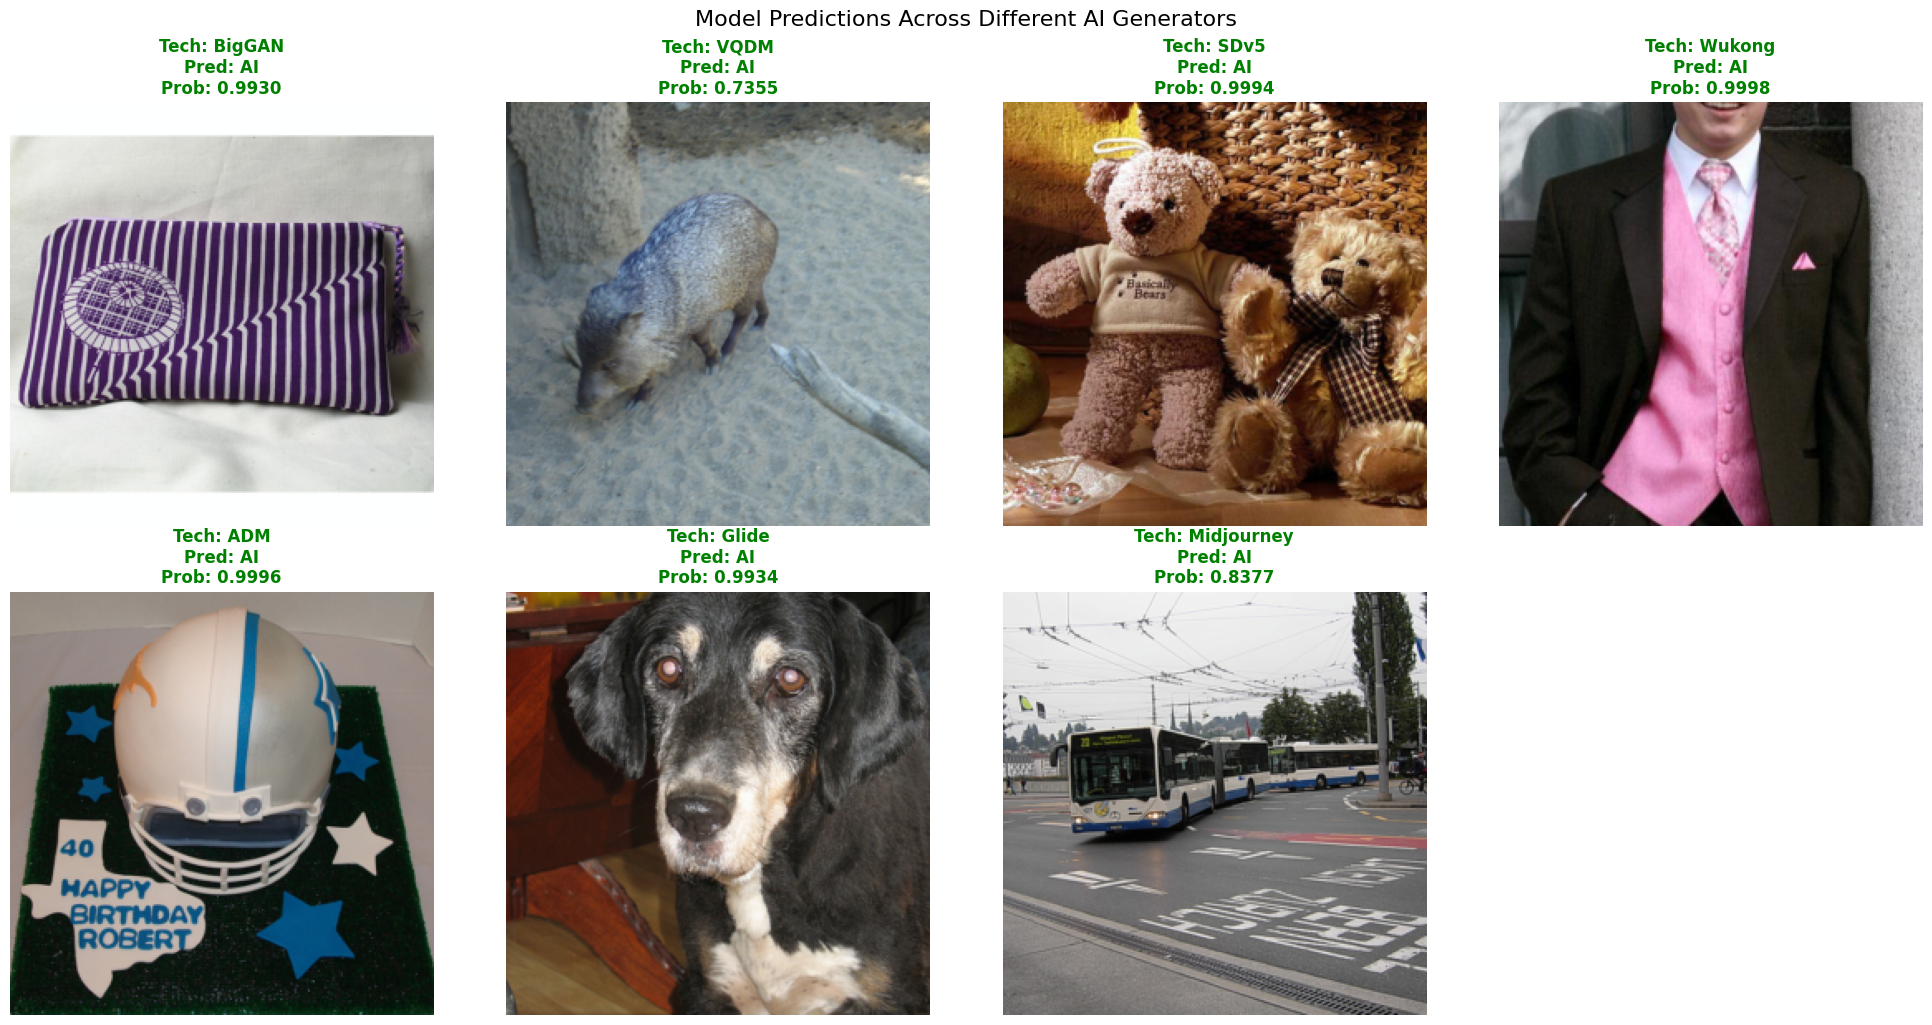

In [ ]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def visualize_tech_samples(model_path, data_root, device, transform):
    model = ssp().to(device)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
    else:
        print("Model weights not found. Please check path.")
        return

    techs = {
        'BigGAN': 'imagenet_ai_0419_biggan',
        'VQDM': 'imagenet_ai_0419_vqdm',
        'SDv5': 'imagenet_ai_0424_sdv5',
        'Wukong': 'imagenet_ai_0424_wukong',
        'ADM': 'imagenet_ai_0508_adm',
        'Glide': 'imagenet_glide',
        'Midjourney': 'imagenet_midjourney'
    }

    plt.figure(figsize=(20, 10))

    for i, (name, folder) in enumerate(techs.items()):

        tech_path = os.path.join(data_root, folder, 'val')


        subfolders = sorted([f for f in os.listdir(tech_path) if os.path.isdir(os.path.join(tech_path, f))])
        fake_folder = subfolders[1] if len(subfolders) > 1 else subfolders[0]

        img_folder_path = os.path.join(tech_path, fake_folder)
        img_name = os.listdir(img_folder_path)[0]
        img_path = os.path.join(img_folder_path, img_name)

        raw_img = Image.open(img_path).convert('RGB')
        input_tensor = transform(raw_img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.sigmoid(output).item()
            pred = "AI" if prob > 0.5 else "Real"

        plt.subplot(2, 4, i+1)

        img_display = input_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
        img_display = img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_display = np.clip(img_display, 0, 1)

        plt.imshow(img_display)
        color = 'green' if pred == "AI" else 'red'
        plt.title(f"Tech: {name}\nPred: {pred}\nProb: {prob:.4f}", color=color, fontsize=12, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Model Predictions Across Different AI Generators", fontsize=16, y=1.02)
    plt.savefig('tech_comparison.png')
    plt.show()

visualize_tech_samples(
    model_path=os.path.join(opt.save_path, 'Net_epoch_best.pth'),
    data_root="/content/tiny_genimage",
    device=DEVICE,
    transform=val_test_transforms
)